In [1]:
import zipfile

with zipfile.ZipFile('Data/MZ Projekt V1.zip', 'r') as zip_ref:
    zip_ref.extractall('Data/MZ Projekt V1')

In [4]:
with zipfile.ZipFile('Data/MZ Projekt V1/Negativ 12241515.zip', 'r') as zip_ref:
    zip_ref.extractall('Data/Negativ 12241515')

with zipfile.ZipFile('Data/MZ Projekt V1/Pos_neg 12241515.zip', 'r') as zip_ref:
    zip_ref.extractall('Data/Pos_neg 12241515')

In [11]:
import os
from collections import Counter

# Pfad zu deinem Ordner mit den Label-Dateien
label_folder = r'C:\Users\Flo\Desktop\Studium\6. Semester\BA\Data\Pos_neg 12241515\labels\Train'  # Passe diesen Pfad an

def count_yolo_classes(folder_path):
    class_counts = Counter()
    file_count = 0

    if not os.path.exists(folder_path):
        print(f"Fehler: Der Ordner {folder_path} wurde nicht gefunden.")
        return

    for filename in os.listdir(folder_path):
        if filename.endswith('.txt'):
            file_count += 1
            with open(os.path.join(folder_path, filename), 'r') as f:
                for line in f:
                    parts = line.split()
                    if parts:
                        # Die erste Zahl in der Zeile ist die Klassen-ID
                        class_id = parts[0]
                        class_counts[class_id] += 1

    print(f"--- Analyse abgeschlossen ---")
    print(f"Anzahl bearbeiteter Dateien: {file_count}")
    print("Verteilung der Klassen (ID: Anzahl Bounding Boxes):")
    for cid, count in sorted(class_counts.items()):
        # Hier kannst du die Namen manuell ergänzen, z.B. 0: 'Atypisch', 1: 'Normal'
        label_name = "Atypisch" if cid == '0' else "Normal"
        print(f"  Klasse {cid} ({label_name}): {count}")

In [12]:
count_yolo_classes(label_folder)

--- Analyse abgeschlossen ---
Anzahl bearbeiteter Dateien: 481
Verteilung der Klassen (ID: Anzahl Bounding Boxes):
  Klasse 0 (Atypisch): 638


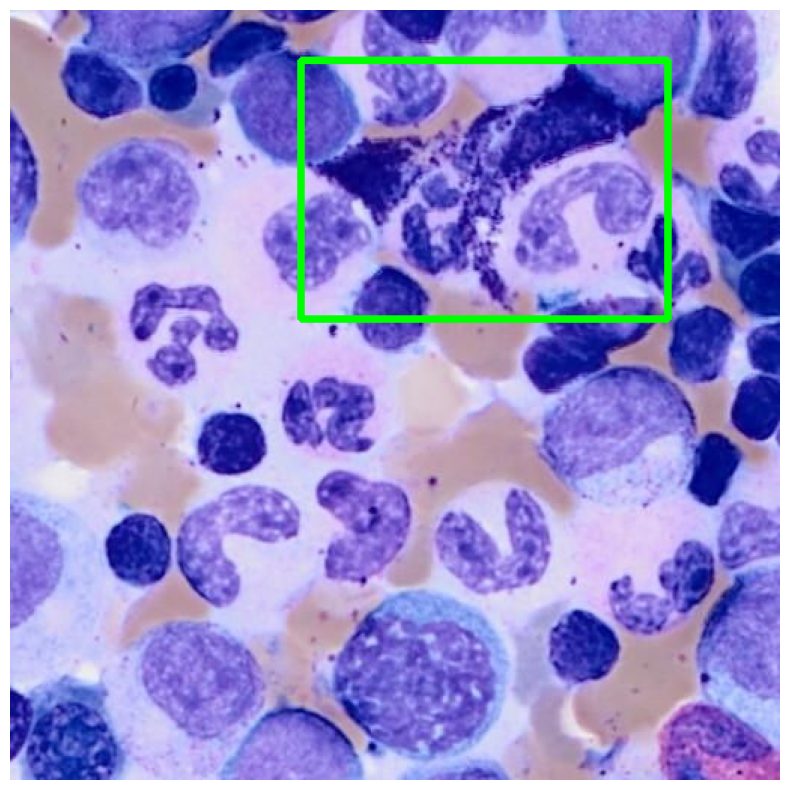

In [2]:
import cv2
import os
import matplotlib.pyplot as plt

# Pfade anpassen
image_path = r'C:\Users\Flo\Desktop\Studium\6. Semester\BA\Data\Pos_neg 12241515\images\Train\tile_0_23.jpg'
label_path = r'C:\Users\Flo\Desktop\Studium\6. Semester\BA\Data\Pos_neg 12241515\labels\Train\tile_0_23.txt'

def show_boxes_stable(img_path, lbl_path):
    if not os.path.exists(img_path):
        print(f"Fehler: Bild nicht gefunden unter {img_path}")
        return

    # Bild laden
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # OpenCV lädt BGR, Matplotlib braucht RGB
    h, w, _ = img.shape

    # Labels einlesen, falls vorhanden
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.split()
                if len(parts) == 5:
                    class_id, x_c, y_c, bw, bh = map(float, parts)
                    
                    # Umrechnen von normierten YOLO-Werten in Pixel
                    x1 = int((x_c - bw / 2) * w)
                    y1 = int((y_c - bh / 2) * h)
                    x2 = int((x_c + bw / 2) * w)
                    y2 = int((y_c + bh / 2) * h)

                    # Zeichnen
                    color = (0, 255, 0) if int(class_id) == 0 else (255, 0, 0)
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 3)
                    plt.text(x1, y1-5, f"ID: {int(class_id)}", color='white', 
                             fontsize=8, bbox=dict(facecolor='red', alpha=0.5))

    # Bild ausgeben
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

show_boxes_stable(image_path, label_path)
